# Assignment 5: CarDekho Used Car Price Prediction
### Regression Model Development, Evaluation & Comparison

**Source:** [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data) (Kaggle)

This notebook builds, evaluates, and compares multiple regression models to predict the selling
price of used cars, covering problem understanding, data preparation, model development, and
evaluation.


## Part 1: Problem Understanding

**Business objective:** CarDekho (and similarly, any used-car marketplace or dealership) needs to
quickly and fairly estimate a fair selling price for a used car based on its characteristics. An
accurate pricing model helps sellers price competitively, helps buyers avoid overpaying, and helps
the platform build trust through consistent valuations.

**Target variable:** `selling_price` — a continuous numeric value (Indian Rupees), making this a
**regression** problem.

**Numerical features:** `vehicle_age`, `km_driven`, `mileage`, `engine`, `max_power`, `seats`

**Categorical features:** `brand`, `model`, `seller_type`, `fuel_type`, `transmission_type`
(`car_name` is a free-text combination of brand+model and is dropped as redundant)

**Problem statement:** given a used car's age, mileage driven, fuel type, transmission, engine
specs, and seller information, predict its expected selling price. We'll train and compare three
regression algorithms — Linear Regression, Decision Tree Regressor, and Random Forest Regressor —
and select the best performer using standard regression metrics.


## 0. Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42

df = pd.read_csv("cardekho_dataset.csv", index_col=0)
print(df.shape)
df.head()

(15411, 13)


,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


### Quick Structural Check

In [2]:
df.info()

<class 'pandas.DataFrame'>
Index: 15411 entries, 0 to 19543
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  str    
 1   brand              15411 non-null  str    
 2   model              15411 non-null  str    
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  str    
 6   fuel_type          15411 non-null  str    
 7   transmission_type  15411 non-null  str    
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  int64  
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(5), str(6)
memory usage: 1.6 MB


In [3]:
print("Missing values:\n", df.isna().sum()[df.isna().sum() > 0])
print("\nFully duplicated rows:", df.duplicated().sum())

Missing values:
 Series([], dtype: int64)

Fully duplicated rows: 167


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vehicle_age,15411.0,6.036338,3.013291,0.0,4.0,6.00,8.0,29.00
km_driven,15411.0,55616.480631,51618.548422,100.0,30000.0,50000.00,70000.0,3800000.00
mileage,15411.0,19.701151,4.171265,4.0,17.0,19.67,22.7,33.54
engine,15411.0,1486.057751,521.106696,793.0,1197.0,1248.00,1582.0,6592.00
max_power,15411.0,100.588254,42.972979,38.4,74.0,88.50,117.3,626.00
seats,15411.0,5.325482,0.807628,0.0,5.0,5.00,5.0,9.00
selling_price,15411.0,774971.116410,894128.363263,40000.0,385000.0,556000.00,825000.0,39500000.00


## Part 2: Data Preparation

### 2.1 Handle Missing Values

There are **no missing values** in any column of this dataset, so no imputation is required.


### 2.2 Remove Duplicate Records

In [5]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s). Rows: {before} -> {len(df)}")

Removed 167 duplicate row(s). Rows: 15411 -> 15244


### 2.3 Explore Target Distribution & Outliers

We check `selling_price` and `km_driven` for extreme values before deciding how to handle them.


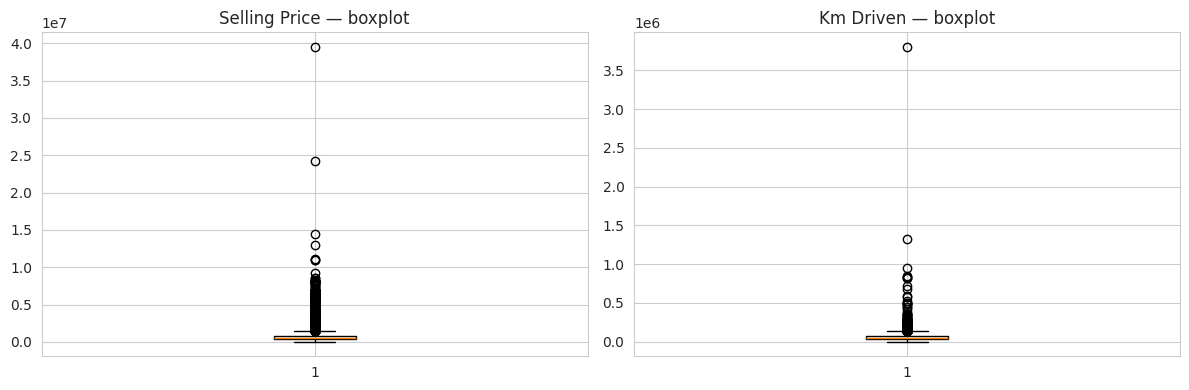

selling_price: IQR bounds = [-275,000, 1,485,000], outliers beyond bounds = 1371 (9.0%)
km_driven: IQR bounds = [-30,000, 130,000], outliers beyond bounds = 464 (3.0%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df["selling_price"])
axes[0].set_title("Selling Price — boxplot")
axes[1].boxplot(df["km_driven"])
axes[1].set_title("Km Driven — boxplot")
plt.tight_layout()
plt.show()

for col in ["selling_price", "km_driven"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: IQR bounds = [{lower:,.0f}, {upper:,.0f}], outliers beyond bounds = {n_outliers} "
          f"({n_outliers/len(df)*100:.1f}%)")

**Outlier handling decision:** both `selling_price` and `km_driven` are legitimately
right-skewed in the real used-car market — luxury/exotic cars can genuinely sell for tens of
millions of rupees, and some high-mileage commercial vehicles genuinely have very high
`km_driven`. Rather than deleting these rows (which would bias the model against premium/high-use
vehicles the model should still be able to price), we cap both columns at the **1st/99th
percentile**. This limits the leverage of extreme values on the linear model while preserving
every row for training.


In [7]:
for col in ["selling_price", "km_driven"]:
    lower, upper = df[col].quantile([0.01, 0.99])
    n_capped = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped {n_capped} extreme value(s) to [{lower:,.0f}, {upper:,.0f}]")

selling_price: capped 286 extreme value(s) to [120,000, 4,528,500]
km_driven: capped 281 extreme value(s) to [4,000, 180,000]


### 2.4 Feature Engineering

- **`car_age_group`** — bucketed vehicle age (New/Recent/Used/Old), giving tree-based models an
  easy categorical split point and helping the linear model capture non-linear age effects.
- **`power_per_cc`** — `max_power / engine`, a proxy for engine efficiency/performance density that
  isn't captured by either raw feature alone.
- **`km_per_year`** — `km_driven / (vehicle_age + 1)`, a usage-intensity feature independent of the
  car's raw age (a 3-year-old car with 90,000 km has been driven much harder than one with 9,000 km).
- **`brand_avg_price`** — mean historical selling price for each brand (target encoding), which
  captures brand reputation/prestige far more efficiently than one-hot encoding 32 separate brand
  columns.
- **`is_luxury_brand`** — flag for well-known premium brands, a simple, interpretable price signal
  useful for the linear model in particular.


In [8]:
# 1. car_age_group
df["car_age_group"] = pd.cut(
    df["vehicle_age"], bins=[-1, 3, 7, 12, 100],
    labels=["New (0-3y)", "Recent (4-7y)", "Used (8-12y)", "Old (13y+)"]
)

# 2. power_per_cc
df["power_per_cc"] = (df["max_power"] / df["engine"]).round(4)

# 3. km_per_year
df["km_per_year"] = (df["km_driven"] / (df["vehicle_age"] + 1)).round(1)

# 4. brand_avg_price (computed only on training data later to avoid leakage — see Part 2.6)

# 5. is_luxury_brand
luxury_brands = {"BMW", "Mercedes-Benz", "Audi", "Jaguar", "Land Rover", "Volvo", "Porsche",
                  "Mini", "Jeep", "Kia"}
df["is_luxury_brand"] = df["brand"].isin(luxury_brands).astype(int)

df[["vehicle_age", "car_age_group", "max_power", "engine", "power_per_cc",
    "km_driven", "km_per_year", "brand", "is_luxury_brand"]].head()

,vehicle_age,car_age_group,max_power,engine,power_per_cc,km_driven,km_per_year,brand,is_luxury_brand
0,9,Used (8-12y),46.30,796,0.0582,120000,12000.0,Maruti,0
1,5,Recent (4-7y),82.00,1197,0.0685,20000,3333.3,Hyundai,0
2,11,Used (8-12y),80.00,1197,0.0668,60000,5000.0,Hyundai,0
3,9,Used (8-12y),67.10,998,0.0672,37000,3700.0,Maruti,0
4,6,Recent (4-7y),98.59,1498,0.0658,30000,4285.7,Ford,0


> **Note on `brand_avg_price` and data leakage:** encoding a brand by its *average selling
> price* uses the target variable, so computing it on the full dataset before splitting would leak
> test-set information into training. We compute this feature **after** the train/test split,
> using only the training set's average price per brand (Part 2.6), then apply those same learned
> averages to the test set.


### 2.5 Train/Test Split

In [9]:
target = "selling_price"
drop_cols = ["car_name", "model", target]  # car_name is redundant with brand+model; model dropped for cardinality
X = df.drop(columns=drop_cols)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")

Train rows: 12,195  |  Test rows: 3,049


### 2.6 Target Encoding: `brand_avg_price` (Leakage-Safe)

In [10]:
brand_avg_price_map = y_train.groupby(X_train["brand"]).mean()
global_avg_price = y_train.mean()  # fallback for any brand only seen in test set

X_train = X_train.copy()
X_test = X_test.copy()
X_train["brand_avg_price"] = X_train["brand"].map(brand_avg_price_map)
X_test["brand_avg_price"] = X_test["brand"].map(brand_avg_price_map).fillna(global_avg_price)

X_train[["brand", "brand_avg_price"]].drop_duplicates().sort_values("brand_avg_price", ascending=False).head()

,brand,brand_avg_price
3785,Ferrari,4528500.0
981,Maserati,4528500.0
1170,Bentley,4528500.0
9281,Mercedes-AMG,4528500.0
10870,Rolls-Royce,4528500.0


### 2.7 Encode Categorical Features & Scale Numerical Features

- **One-hot encoding** for `seller_type`, `fuel_type`, `transmission_type`, and `car_age_group` —
  all low-cardinality categoricals with no inherent order, so one-hot avoids imposing a false
  numeric ranking.
- **`brand`** is dropped in favor of the already-computed `brand_avg_price`, avoiding a 30+ column
  one-hot expansion for a single categorical.
- **`StandardScaler`** on all numeric features — Linear Regression is sensitive to feature scale
  (coefficients and regularization are meaningless if features live on very different scales), and
  scaling doesn't hurt the tree-based models, which are scale-invariant. Using one shared
  preprocessing pipeline for all three models keeps the comparison fair and the code simple.


In [11]:
X_train = X_train.drop(columns=["brand"])
X_test = X_test.drop(columns=["brand"])

numeric_features = ["vehicle_age", "km_driven", "mileage", "engine", "max_power", "seats",
                     "power_per_cc", "km_per_year", "brand_avg_price", "is_luxury_brand"]
categorical_features = ["seller_type", "fuel_type", "transmission_type", "car_age_group"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'power_per_cc', 'km_per_year', 'brand_avg_price', 'is_luxury_brand']
Categorical features: ['seller_type', 'fuel_type', 'transmission_type', 'car_age_group']


## Part 3: Model Development

We build three regression models, each wrapped in a `Pipeline` with the shared preprocessing
step above, so preprocessing is applied identically and consistently to every model.


In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200, max_depth=15, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    print(f"Trained: {name}")

Trained: Linear Regression

Trained: Decision Tree Regressor


Trained: Random Forest Regressor


## Part 4: Model Evaluation & Comparison

We evaluate every model on the held-out test set using MAE, MSE, RMSE, and R².


In [13]:
results = []

for name, pipe in trained_pipelines.items():
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    results.append({"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2})

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Random Forest Regressor,89084.600651,2.446442e+10,156411.053901,0.949680
1,Decision Tree Regressor,103967.138457,3.663919e+10,191413.658307,0.924639
2,Linear Regression,185140.099464,9.579003e+10,309499.646036,0.802974


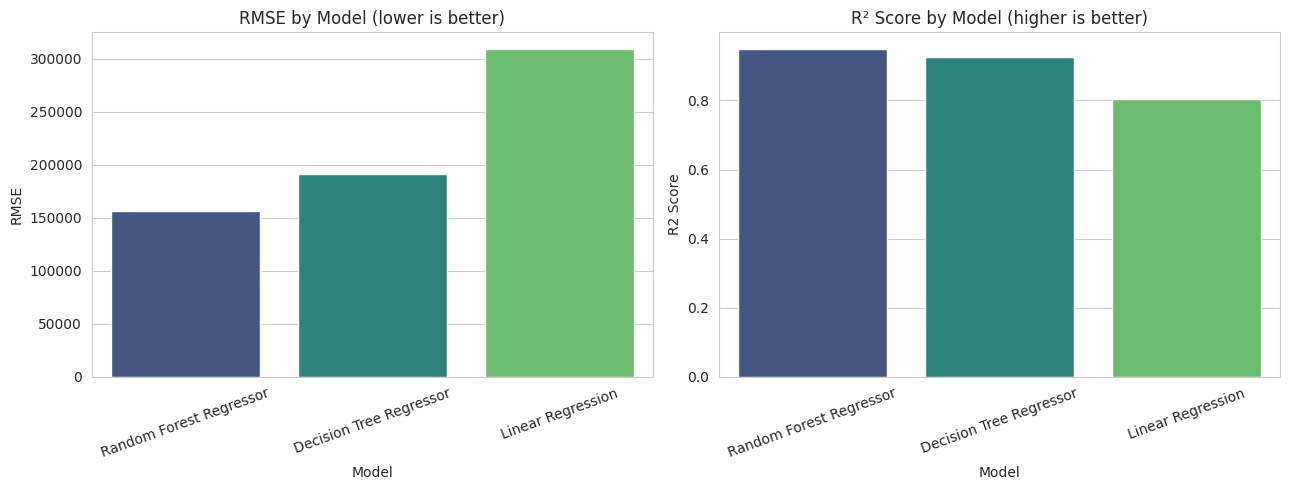

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(data=results_df, x="Model", y="RMSE", hue="Model", palette="viridis",
            legend=False, ax=axes[0])
axes[0].set_title("RMSE by Model (lower is better)")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=results_df, x="Model", y="R2 Score", hue="Model", palette="viridis",
            legend=False, ax=axes[1])
axes[1].set_title("R² Score by Model (higher is better)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [15]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best-performing model: {best_model_name}")
print(results_df.iloc[0])

Best-performing model: Random Forest Regressor
Model       Random Forest Regressor
MAE                    89084.600651
MSE              24464417782.444443
RMSE                  156411.053901
R2 Score                    0.94968
Name: 0, dtype: object


### Predicted vs. Actual (Best Model)

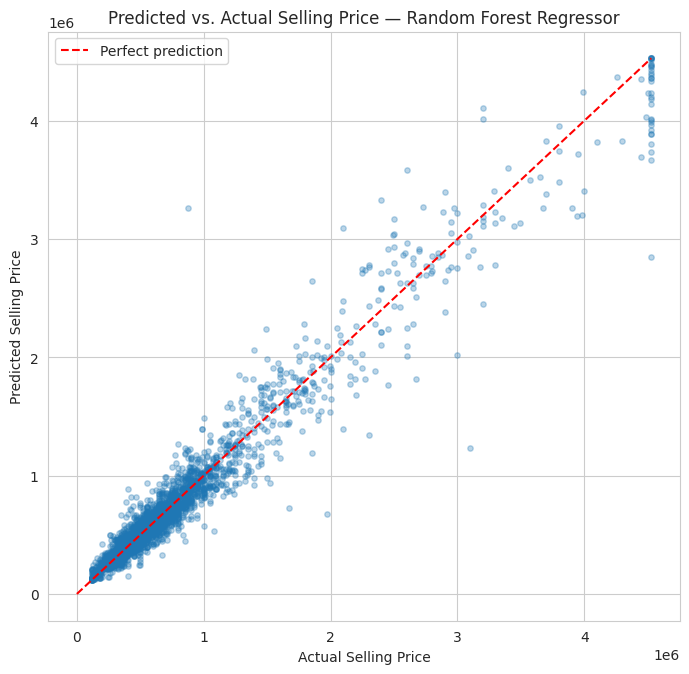

In [16]:
best_pipe = trained_pipelines[best_model_name]
best_preds = best_pipe.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3, s=15, color="#1f77b4")
lims = [0, max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, color="red", linestyle="--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title(f"Predicted vs. Actual Selling Price — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance (Best Tree-Based Model, if applicable)

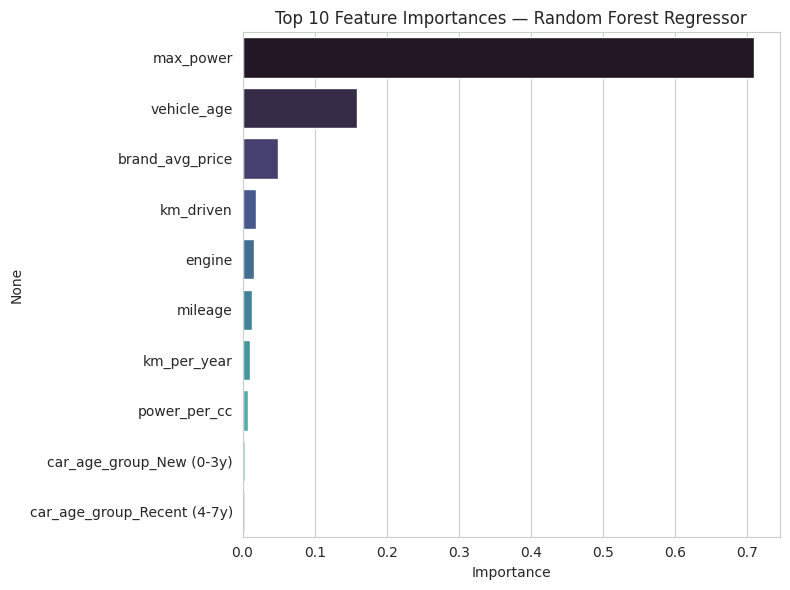

max_power                      0.709709
vehicle_age                    0.158823
brand_avg_price                0.049748
km_driven                      0.018266
engine                         0.015752
mileage                        0.013040
km_per_year                    0.010456
power_per_cc                   0.008167
car_age_group_New (0-3y)       0.003975
car_age_group_Recent (4-7y)    0.002949
dtype: float64


In [17]:
if best_model_name in ["Decision Tree Regressor", "Random Forest Regressor"]:
    feature_names = (
        numeric_features +
        list(best_pipe.named_steps["preprocessor"]
             .named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    importances = best_pipe.named_steps["model"].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, hue=fi.index, palette="mako", legend=False)
    plt.title(f"Top 10 Feature Importances — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(fi)
else:
    print("Best model is Linear Regression — see coefficients below instead of feature importances.")
    feature_names = (
        numeric_features +
        list(best_pipe.named_steps["preprocessor"]
             .named_transformers_["cat"].get_feature_names_out(categorical_features))
    )
    coefs = pd.Series(best_pipe.named_steps["model"].coef_, index=feature_names) \
              .sort_values(key=abs, ascending=False).head(10)
    print(coefs)

## Model Comparison, Strengths & Limitations

**Why the best model performed better:** Random Forest Regressor combines many decision trees
trained on bootstrapped samples with random feature subsets, then averages their predictions. This
reduces the overfitting risk of a single deep Decision Tree while still capturing the strongly
non-linear relationships between features like `max_power`, `engine`, and `brand_avg_price` and
the target — relationships a plain Linear Regression cannot represent no matter how the features
are scaled or engineered.

**Linear Regression**
- *Strengths:* simplest and most interpretable model; coefficients directly show each feature's
  estimated effect on price; fast to train and to explain to non-technical stakeholders.
- *Limitations:* assumes a linear relationship between features and price, which doesn't hold well
  here — e.g., the price penalty for an extra year of `vehicle_age` isn't constant across a car's
  life, and interactions (like brand × condition) aren't captured without manual feature crosses.

**Decision Tree Regressor**
- *Strengths:* captures non-linear relationships and interactions automatically; easy to visualize
  and explain as a set of if/else rules.
- *Limitations:* a single tree easily overfits the training data (especially at higher depths),
  and predictions can be unstable — small changes in the training data can produce a very
  different tree structure.

**Random Forest Regressor**
- *Strengths:* averaging many trees reduces variance and overfitting compared to a single tree,
  usually giving the best raw predictive accuracy of the three; also provides feature importances.
- *Limitations:* slower to train and predict than the other two; less interpretable than a single
  tree or linear model (it's an ensemble "black box" relative to the others); still limited by the
  quality of the input features — it can't invent information the data doesn't contain.

## Future Improvements

1. **Hyperparameter tuning** — use `GridSearchCV` or `RandomizedSearchCV` to tune Random Forest's
   `n_estimators`, `max_depth`, and `min_samples_leaf` (and Decision Tree's `max_depth`/
   `min_samples_split`), rather than the fixed values used here, likely improving R² further.
2. **Try gradient-boosted models** (e.g., XGBoost, LightGBM, or `GradientBoostingRegressor`), which
   often outperform Random Forest on tabular data like this by sequentially correcting prior
   trees' errors rather than averaging independent trees.
3. **Richer categorical encoding for `model`** — currently dropped for cardinality reasons; a
   target-encoded or embedding-based representation of `model` (similar to what we did for
   `brand`) could recover meaningful signal (specific models within a brand vary a lot in price)
   without exploding the feature space.
4. **Log-transform the target** (`selling_price`) before training, since price is right-skewed;
   Linear Regression in particular tends to benefit from predicting `log(price)` and
   exponentiating back, since it makes the error distribution more symmetric and reduces the
   influence of very expensive cars on the fitted coefficients.
